### Импорты

In [1]:
from chython.files import SDFRead
import pandas as pd
import numpy as np
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC 
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (make_scorer, balanced_accuracy_score,
 confusion_matrix, classification_report, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import umap

/home/skvortsovea/.conda/envs/env_qsar_furanones/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Классификационная QSAR-модель,по предсказыванию антигрибковой активности фуранонов в отношении Aspergillus niger 

#### Подготовка дескрипторов:

In [2]:
# === 1) Загрузка данных и генерация дескрипторов ===
def load_fingerprints_sdf(path, target=('МПК Aspergillus niger, мкг/мл', 'МПК Alternaria alternata, мкг/мл')):
    """
    Читает SDF, генерирует fingerprint длины 2048,
    возвращает array дескрипторов X1, array булевых значений Y1,
    датафрейм df_X1 по оригинальным переменным.
    """
    # 1) Читаем SDF
    with SDFRead(path) as f:
        furanones_list = f.read()
    # 2) Генерируем дескрипторы
    fingerprint_list = [mol.linear_fingerprint(length=2048)
                        for mol in furanones_list]
    X1 = np.vstack(fingerprint_list)
    # 3) Извлечение ID и активности
    ids, activity = [], []
    for mol in furanones_list:
        ids.append(mol.meta['id'])
        mic_str = mol.meta[f'{target}'].strip()
        activity.append(False if mic_str.startswith('>') else True)
    Y1 = np.array(activity, dtype=bool)
    # 4) DataFrame
    df_X1 = pd.DataFrame(X1,
                         columns=[f"fp_{i+1}" for i in range(X1.shape[1])])
    df_X1.insert(0, "ID", ids)
    df_X1["Activity"] = Y1
    return X1, Y1, df_X1


X1, Y1, df_X1 = load_fingerprints_sdf("/home/skvortsovea/qsar_furanones/furanones_sdf_Clean_2d_without_dublicates.sdf", 'МПК Aspergillus niger, мкг/мл')
df_X1


,ID,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047,fp_2048,Activity
0,A7,1,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,False
1,A8,1,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,False
2,A9,1,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,False
3,A10,1,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,False
4,A11,1,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,T8,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,False
256,T9,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,False
257,T10,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,False
258,T11,0,0,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,False


#### Визулизация данных: Гистограмма и UMAP

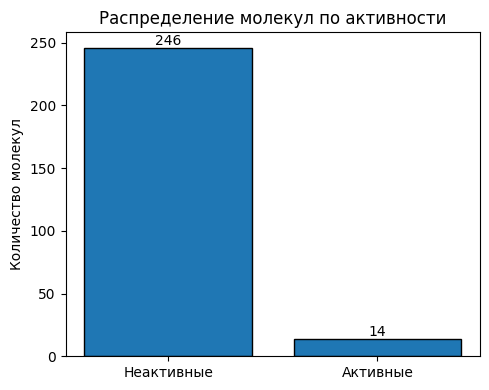

In [9]:
# Гистограмма активности
# Показывает, сколько молекул активных и неактивных в выборке
def plot_activity_histogram(Y):
    """Строит гистограмму: сколько активных и неактивных молекул"""
    activity_counts = pd.Series(Y).value_counts()
    labels = ['Неактивные', 'Активные']
    # извлекаем количество из activity_counts
    values = [int(activity_counts.get(False, 0)), int(activity_counts.get(True, 0))]

    plt.figure(figsize=(5, 4))
    plt.bar(labels, values, edgecolor='black')
    # Добавим подписи значений над столбцами
    for i, v in enumerate(values):
        plt.text(i, v + max(values)*0.01, str(v), ha='center')
    plt.title('Распределение молекул по активности')
    plt.ylabel('Количество молекул')
    plt.tight_layout()
    plt.show()

plot_activity_histogram(Y1)

/home/skvortsovea/.conda/envs/env_qsar_furanones/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/skvortsovea/.conda/envs/env_qsar_furanones/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


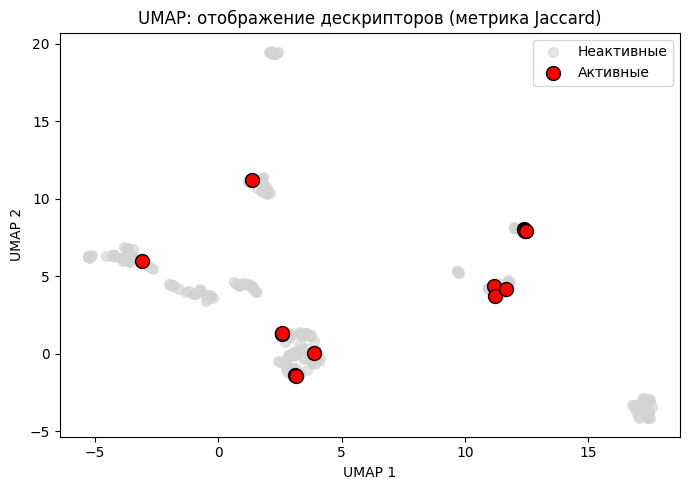

In [17]:
def plot_umap_fingerprints(X, Y):
    """Выполняет UMAP с метрикой Jaccard и рисует активные/неактивные точки"""
    # Снижаем размерность X до 2D с помощью UMAP и метрики Жаккарда
    umap_model = umap.UMAP(
        n_neighbors=15,    # число соседей для понимания локальной структуры
        min_dist=0.1,      # минимальное расстояние между точками
        n_components=2,    # два измерения для визуализации
        metric='jaccard',  # метрика Жаккарда для бинарных векторов
        random_state=42
    )

    X_embedded = umap_model.fit_transform(X)

    # Визуализация: точки активных и неактивных молекул
    plt.figure(figsize=(7, 5))
    # Рисуем неактивные серым фоном
    plt.scatter(
        X_embedded[~Y, 0], X_embedded[~Y, 1],
        label='Неактивные', color='lightgray', alpha=0.6, s=50, zorder=1
    )
    # Рисуем активные красным сверху
    plt.scatter(
        X_embedded[Y, 0], X_embedded[Y, 1],
        label='Активные', color='red', edgecolor='black', s=100, zorder=2
    )
    plt.legend()
    plt.title('UMAP: отображение дескрипторов (метрика Jaccard)')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.tight_layout()
    plt.show()

plot_umap_fingerprints(X1, Y1)


#### Построение методом RandomForest:

In [10]:
# === 4) Подбор гиперпараметров RandomForest ===
def gridsearch_rf(X, Y, n_jobs=4):
    """
    Выполняет GridSearchCV по balanced_accuracy_score,
    возвращает объект gs и DataFrame results.
    """
    # Словарь метрик
    scorers = {
        'balanced_acc': make_scorer(balanced_accuracy_score)
    }

    # Задаём сетку гиперпараметров
    # Перебираем разное число деревьев, глубину и количество дескрипторов для построения одного дерева
    param_grid = {
        'n_estimators': [100, 200, 500],
        'max_depth': [None, 10, 20],
        'max_features':['sqrt', 'log2', None]
    }

    # StratifiedKFold для маленьких наборов данных
    # Делим на 5 частей, сохраняя долю активных/неактивных в каждой
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # GridSearchCV — подбор лучших параметров
    rf = RandomForestClassifier(random_state=42)
    gs = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring=scorers, # указываем перечень наших метрик
        refit='balanced_acc',   # по какой метрике выбрать лучшую модель и переобучить на всех данных
        cv=cv,  # схема разбиения на фолды
        return_train_score=True,
        n_jobs= 4  # использовать 4 ядер
    )
    # Запускаем подбор параметров
    gs.fit(X, Y)
    # После завершения: gs.best_params_ содержит лучшие гиперпараметры,
    # gs.best_score_ — лучший средний balanced_accuracy_score
    print("Best parameters:", gs.best_params_)
    print("Best balanced accuracy:", gs.best_score_)

    # Сводка результатов
    results = pd.DataFrame(gs.cv_results_)
    return gs, cv,  results


gs1, cv1,  results1 = gridsearch_rf(X1, Y1)
# results

Best parameters: {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 100}
Best balanced accuracy: 0.629251700680272


Cross-validated Balanced Accuracy: 0.639
Cross-validated ROC AUC: 0.740

Отчёт классификации:
              precision    recall  f1-score   support

  Неактивная       0.96      0.99      0.98       246
    Активная       0.67      0.29      0.40        14

    accuracy                           0.95       260
   macro avg       0.81      0.64      0.69       260
weighted avg       0.94      0.95      0.94       260

Матрица ошибок (строки: реальные, столбцы: предсказанные):
                 Пред Неактивная  Пред Активная
Реал Неактивная              244              2
Реал Активная                 10              4


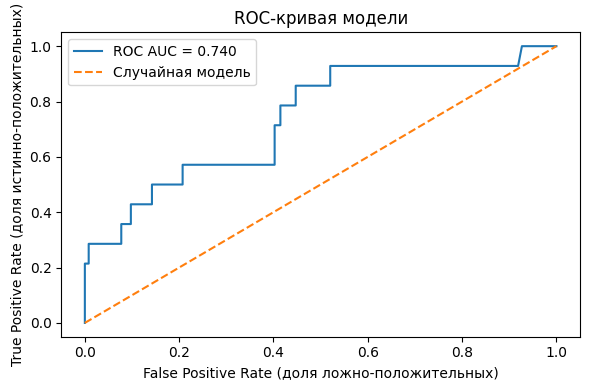

In [11]:
# === 5) Оценка предсказательной способности ===
def evaluate_rf(gs, cv, X, Y):
    """
    Оценивает модель gs на X и Y через cross_val_predict,
    печатает метрики и строит ROC-кривую.
    """
    # Оценка предсказательной способности модели
    # Используем cross_val_predict, чтобы получить честные прогнозы для каждой молекулы
    y_pred = cross_val_predict(gs.best_estimator_, X, Y, cv=cv)  # вектор распределения тру фолз
    y_proba = cross_val_predict(gs.best_estimator_, X, Y, cv=cv, method='predict_proba')[:, 1]  # вектор вероятности причисления к классу

    # Рассчитаем ключевые метрики на этих прогнозах
    bal_acc = balanced_accuracy_score(Y, y_pred)
    roc_auc = roc_auc_score(Y, y_proba)
    print(f"Cross-validated Balanced Accuracy: {bal_acc:.3f}")
    print(f"Cross-validated ROC AUC: {roc_auc:.3f}")
    # 10.2) Подробный отчёт классификации
    print("\nОтчёт классификации:")
    print(classification_report(Y, y_pred, target_names=['Неактивная','Активная']))

    # Матрица ошибок (confusion matrix)
    cm = confusion_matrix(Y, y_pred)
    print("Матрица ошибок (строки: реальные, столбцы: предсказанные):")
    print(pd.DataFrame(cm, index=['Реал Неактивная','Реал Активная'],
                    columns=['Пред Неактивная','Пред Активная']))

    # Построение ROC-кривой для наглядности
    fpr, tpr, _ = roc_curve(Y, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], '--', label='Случайная модель')
    plt.xlabel('False Positive Rate (доля ложно-положительных)')
    plt.ylabel('True Positive Rate (доля истинно-положительных)')
    plt.title('ROC-кривая модели')
    plt.legend()
    plt.tight_layout()
    plt.show()

evaluate_rf(gs1, cv1, X1, Y1)

#### Построение методом SVM:

In [12]:
# === 4) Подбор гиперпараметров RandomForest ===
def gridsearch_svm(X, Y, n_jobs=4):
    """
    Выполняет GridSearchCV для SVM по balanced_accuracy_score,
    возвращает объект gs, cv и DataFrame results.
    """
    # Словарь метрик
    scorers = {
        'balanced_acc': make_scorer(balanced_accuracy_score)
    }

    # Задаём сетку гиперпараметров
    param_grid = {
    'C': [0.1, 1, 10],                     # умеренная сетка
    'kernel': ['linear', 'rbf'],      # оба ядра
    'gamma': ['scale', 'auto'],               # только «scale» по умолчанию
    'class_weight': ['balanced', None]  # чтобы учесть дисбаланс
    }


    # StratifiedKFold для маленьких наборов данных
    # Делим на 5 частей, сохраняя долю активных/неактивных в каждой
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # GridSearchCV — подбор лучших параметров
    svm = SVC(probability=True, random_state=42)  # probability=True для ROC AUC
    gs = GridSearchCV(
        estimator=svm,
        param_grid=param_grid,
        scoring=scorers, # указываем перечень наших метрик
        refit='balanced_acc',   # по какой метрике выбрать лучшую модель и переобучить на всех данных
        cv=cv,  # схема разбиения на фолды
        return_train_score=True,
        n_jobs= 4  # использовать 4 ядер
    )
    # Запускаем подбор параметров
    gs.fit(X, Y)
    # После завершения: gs.best_params_ содержит лучшие гиперпараметры,
    # gs.best_score_ — лучший средний balanced_accuracy_score
    print("Best parameters (SVM):", gs.best_params_)
    print("Best balanced accuracy (SVM):", gs.best_score_)

    # Сводка результатов
    results = pd.DataFrame(gs.cv_results_)
    return gs, cv,  results


gs1_svm, cv1_svm,  results1_svm = gridsearch_svm(X1, Y1)
# results

Best parameters (SVM): {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
Best balanced accuracy (SVM): 0.6821360544217688


Cross-validated Balanced Accuracy: 0.680
Cross-validated ROC AUC: 0.611

Отчёт классификации:
              precision    recall  f1-score   support

  Неактивная       0.97      0.93      0.95       246
    Активная       0.26      0.43      0.32        14

    accuracy                           0.90       260
   macro avg       0.61      0.68      0.64       260
weighted avg       0.93      0.90      0.91       260

Матрица ошибок (строки: реальные, столбцы: предсказанные):
                 Пред Неактивная  Пред Активная
Реал Неактивная              229             17
Реал Активная                  8              6


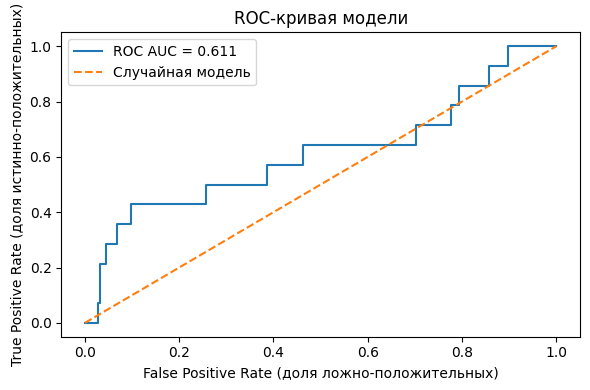

In [13]:
# === 5) Оценка предсказательной способности ===
def evaluate_svm(gs, cv, X, Y):
    """
    Оценивает модель SVM gs на X и Y через cross_val_predict,
    печатает метрики и строит ROC-кривую.
    """
    # Оценка предсказательной способности модели
    # Используем cross_val_predict, чтобы получить честные прогнозы для каждой молекулы
    y_pred = cross_val_predict(gs.best_estimator_, X, Y, cv=cv)  # вектор распределения тру фолз
    y_proba = cross_val_predict(gs.best_estimator_, X, Y, cv=cv, method='predict_proba')[:, 1]  # вектор вероятности причисления к классу

    # Рассчитаем ключевые метрики на этих прогнозах
    bal_acc = balanced_accuracy_score(Y, y_pred)
    roc_auc = roc_auc_score(Y, y_proba)
    print(f"Cross-validated Balanced Accuracy (SVM): {bal_acc:.3f}")
    print(f"Cross-validated ROC AUC (SVM): {roc_auc:.3f}")
    # 10.2) Подробный отчёт классификации
    print("\nОтчёт классификации:")
    print(classification_report(Y, y_pred, target_names=['Неактивная','Активная']))

    # Матрица ошибок (confusion matrix)
    cm = confusion_matrix(Y, y_pred)
    print("Матрица ошибок (строки: реальные, столбцы: предсказанные) (SVM):")
    print(pd.DataFrame(cm, index=['Реал Неактивная','Реал Активная'],
                    columns=['Пред Неактивная','Пред Активная']))

    # Построение ROC-кривой для наглядности
    fpr, tpr, _ = roc_curve(Y, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], '--', label='Случайная модель')
    plt.xlabel('False Positive Rate (доля ложно-положительных)')
    plt.ylabel('True Positive Rate (доля истинно-положительных)')
    plt.title('ROC-кривая модели (SVM)')
    plt.legend()
    plt.tight_layout()
    plt.show()

evaluate_rf(gs1_svm, cv1_svm, X1, Y1)

### Классификационная QSAR-модель,по предсказыванию антигрибковой активности фуранонов в отношении Alternaria alternata 

#### Подготовка дескрипторов:

In [14]:
X2, Y2, df_X2 = load_fingerprints_sdf("/home/skvortsovea/qsar_furanones/furanones_sdf_Clean_2d_without_dublicates.sdf", 'МПК Alternaria alternata, мкг/мл')
df_X2


,ID,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047,fp_2048,Activity
0,A7,1,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,False
1,A8,1,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,False
2,A9,1,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,False
3,A10,1,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,False
4,A11,1,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,T8,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,False
256,T9,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,False
257,T10,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,False
258,T11,0,0,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,False


#### Визулизация данных: Гистограмма и UMAP

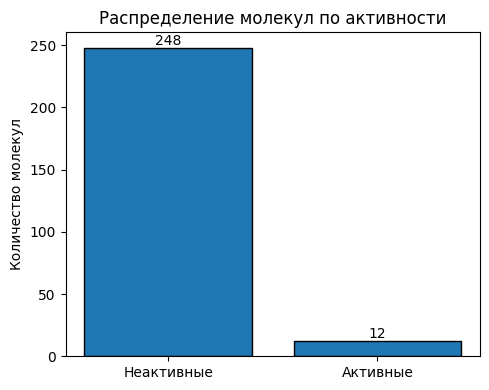

In [15]:
plot_activity_histogram(Y2)

/home/skvortsovea/.conda/envs/env_qsar_furanones/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/skvortsovea/.conda/envs/env_qsar_furanones/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


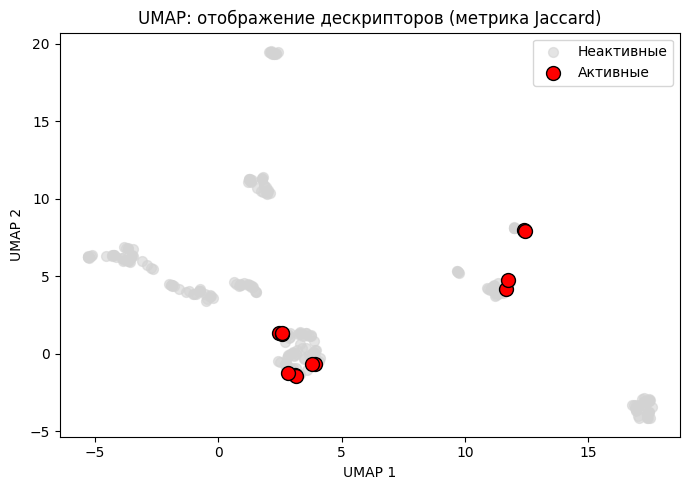

In [18]:
plot_umap_fingerprints(X2, Y2)

#### Построение методом RandomForest:

In [19]:
gs2, cv2,  results2 = gridsearch_rf(X2, Y2)

Best parameters: {'max_depth': None, 'max_features': None, 'n_estimators': 100}
Best balanced accuracy: 0.6646258503401361


Cross-validated Balanced Accuracy: 0.665
Cross-validated ROC AUC: 0.821

Отчёт классификации:
              precision    recall  f1-score   support

  Неактивная       0.97      1.00      0.98       248
    Активная       0.80      0.33      0.47        12

    accuracy                           0.97       260
   macro avg       0.88      0.66      0.73       260
weighted avg       0.96      0.97      0.96       260

Матрица ошибок (строки: реальные, столбцы: предсказанные):
                 Пред Неактивная  Пред Активная
Реал Неактивная              247              1
Реал Активная                  8              4


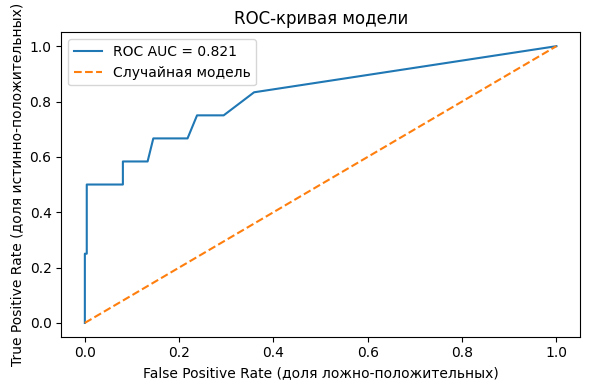

In [20]:
evaluate_rf(gs2, cv2, X2, Y2)

#### Построение методом SVM:

In [21]:
gs2_svm, cv2_svm,  results2_svm = gridsearch_svm(X2, Y2)

Best parameters (SVM): {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best balanced accuracy (SVM): 0.8813877551020408


Cross-validated Balanced Accuracy (SVM): 0.881
Cross-validated ROC AUC (SVM): 0.892

Отчёт классификации:
              precision    recall  f1-score   support

  Неактивная       1.00      0.76      0.86       248
    Активная       0.17      1.00      0.29        12

    accuracy                           0.77       260
   macro avg       0.58      0.88      0.58       260
weighted avg       0.96      0.77      0.84       260

Матрица ошибок (строки: реальные, столбцы: предсказанные) (SVM):
                 Пред Неактивная  Пред Активная
Реал Неактивная              189             59
Реал Активная                  0             12


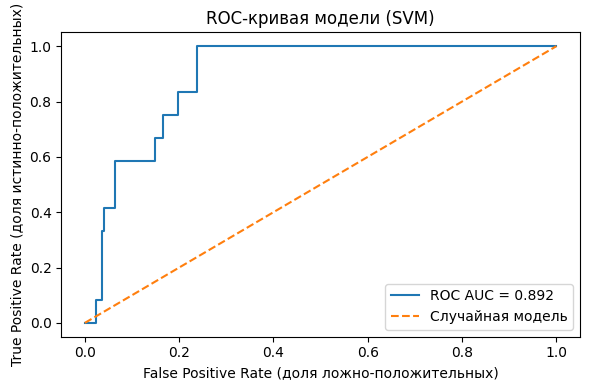

In [22]:
evaluate_svm(gs2_svm, cv2_svm, X2, Y2)